<a href="https://colab.research.google.com/github/sambhavgoel495/customer-churn-prediction-logistic-regression-/blob/main/logistic(customer_churn).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix,precision_score,f1_score,recall_score
from sklearn.preprocessing import StandardScaler

data=pd.read_csv("/content/WA_Fn-UseC_-Telco-Customer-Churn.csv");

data=data.drop('customerID',axis=1)

for column in data.columns:
    print(f"\nColumn: {column}")
    print(data[column].unique())
    print(f"Number of Unique Values: {data[column].nunique()}")
    print("-" * 50)

data

le = LabelEncoder()


Column: gender
['Female' 'Male']
Number of Unique Values: 2
--------------------------------------------------

Column: SeniorCitizen
[0 1]
Number of Unique Values: 2
--------------------------------------------------

Column: Partner
['Yes' 'No']
Number of Unique Values: 2
--------------------------------------------------

Column: Dependents
['No' 'Yes']
Number of Unique Values: 2
--------------------------------------------------

Column: tenure
[ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26  0
 39]
Number of Unique Values: 73
--------------------------------------------------

Column: PhoneService
['No' 'Yes']
Number of Unique Values: 2
--------------------------------------------------

Column: MultipleLines
['No phone service' 'No' 'Yes']
Number of Unique Values: 3
------------------------------------------------

In [3]:
data["gender"] = le.fit_transform(data["gender"])
data["Partner"] = le.fit_transform(data["Partner"])
data["Dependents"] = le.fit_transform(data["Dependents"])
data["PhoneService"] = le.fit_transform(data["PhoneService"])
data["PaperlessBilling"] = le.fit_transform(data["PaperlessBilling"])
data["Churn"] = le.fit_transform(data["Churn"])


one_hot_cols = [
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaymentMethod"
]

data = pd.get_dummies(data, columns=one_hot_cols, drop_first=True, dtype=int)

data


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,...,0,0,0,0,0,0,0,0,1,0
1,1,0,0,0,34,1,0,56.95,1889.5,0,...,0,0,0,0,0,1,0,0,0,1
2,1,0,0,0,2,1,1,53.85,108.15,1,...,0,0,0,0,0,0,0,0,0,1
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,1,0,0,0,0,1,0,0,0,0
4,0,0,0,0,2,1,1,70.70,151.65,1,...,0,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,1,0,1,1,24,1,1,84.80,1990.5,0,...,1,0,1,0,1,1,0,0,0,1
7039,0,0,1,1,72,1,1,103.20,7362.9,0,...,0,0,1,0,1,1,0,1,0,0
7040,0,0,1,1,11,0,1,29.60,346.45,0,...,0,0,0,0,0,0,0,0,1,0
7041,1,1,1,0,4,1,1,74.40,306.6,1,...,0,0,0,0,0,0,0,0,0,1


In [4]:
data["TotalCharges"] = data["TotalCharges"].replace(" ", np.nan)
data["TotalCharges"] = pd.to_numeric(data["TotalCharges"])
data.dropna(inplace=True)
data.info()


<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 7032 non-null   int64  
 1   SeniorCitizen                          7032 non-null   int64  
 2   Partner                                7032 non-null   int64  
 3   Dependents                             7032 non-null   int64  
 4   tenure                                 7032 non-null   int64  
 5   PhoneService                           7032 non-null   int64  
 6   PaperlessBilling                       7032 non-null   int64  
 7   MonthlyCharges                         7032 non-null   float64
 8   TotalCharges                           7032 non-null   float64
 9   Churn                                  7032 non-null   int64  
 10  MultipleLines_No phone service         7032 non-null   int64  
 11  MultipleL

In [5]:
x=data.drop('Churn',axis=1)
y=data['Churn']


scaler = StandardScaler()

num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)



x_train = x_train.drop(columns=["gender"])
x_test = x_test.drop(columns=["gender"])

x_train[num_cols] = scaler.fit_transform(x_train[num_cols])
x_test[num_cols] = scaler.transform(x_test[num_cols])


model=LogisticRegression(class_weight="balanced",
    max_iter=1000,
    random_state=42)
model.fit(x_train,y_train)

y_pred=model.predict(x_test)

accuracy=accuracy_score(y_test,y_pred)
print("Accuracy:",accuracy)


precision = precision_score(y_test, y_pred)
print("Precision:", precision)

cm = confusion_matrix(y_test, y_pred)
print(cm)

recall = recall_score(y_test, y_pred)
print("Recall:", recall)

f1 = f1_score(y_test, y_pred)
print("F1 Score:", f1)

Accuracy: 0.7320540156361052
Precision: 0.49747899159663866
[[734 299]
 [ 78 296]]
Recall: 0.7914438502673797
F1 Score: 0.6109391124871001


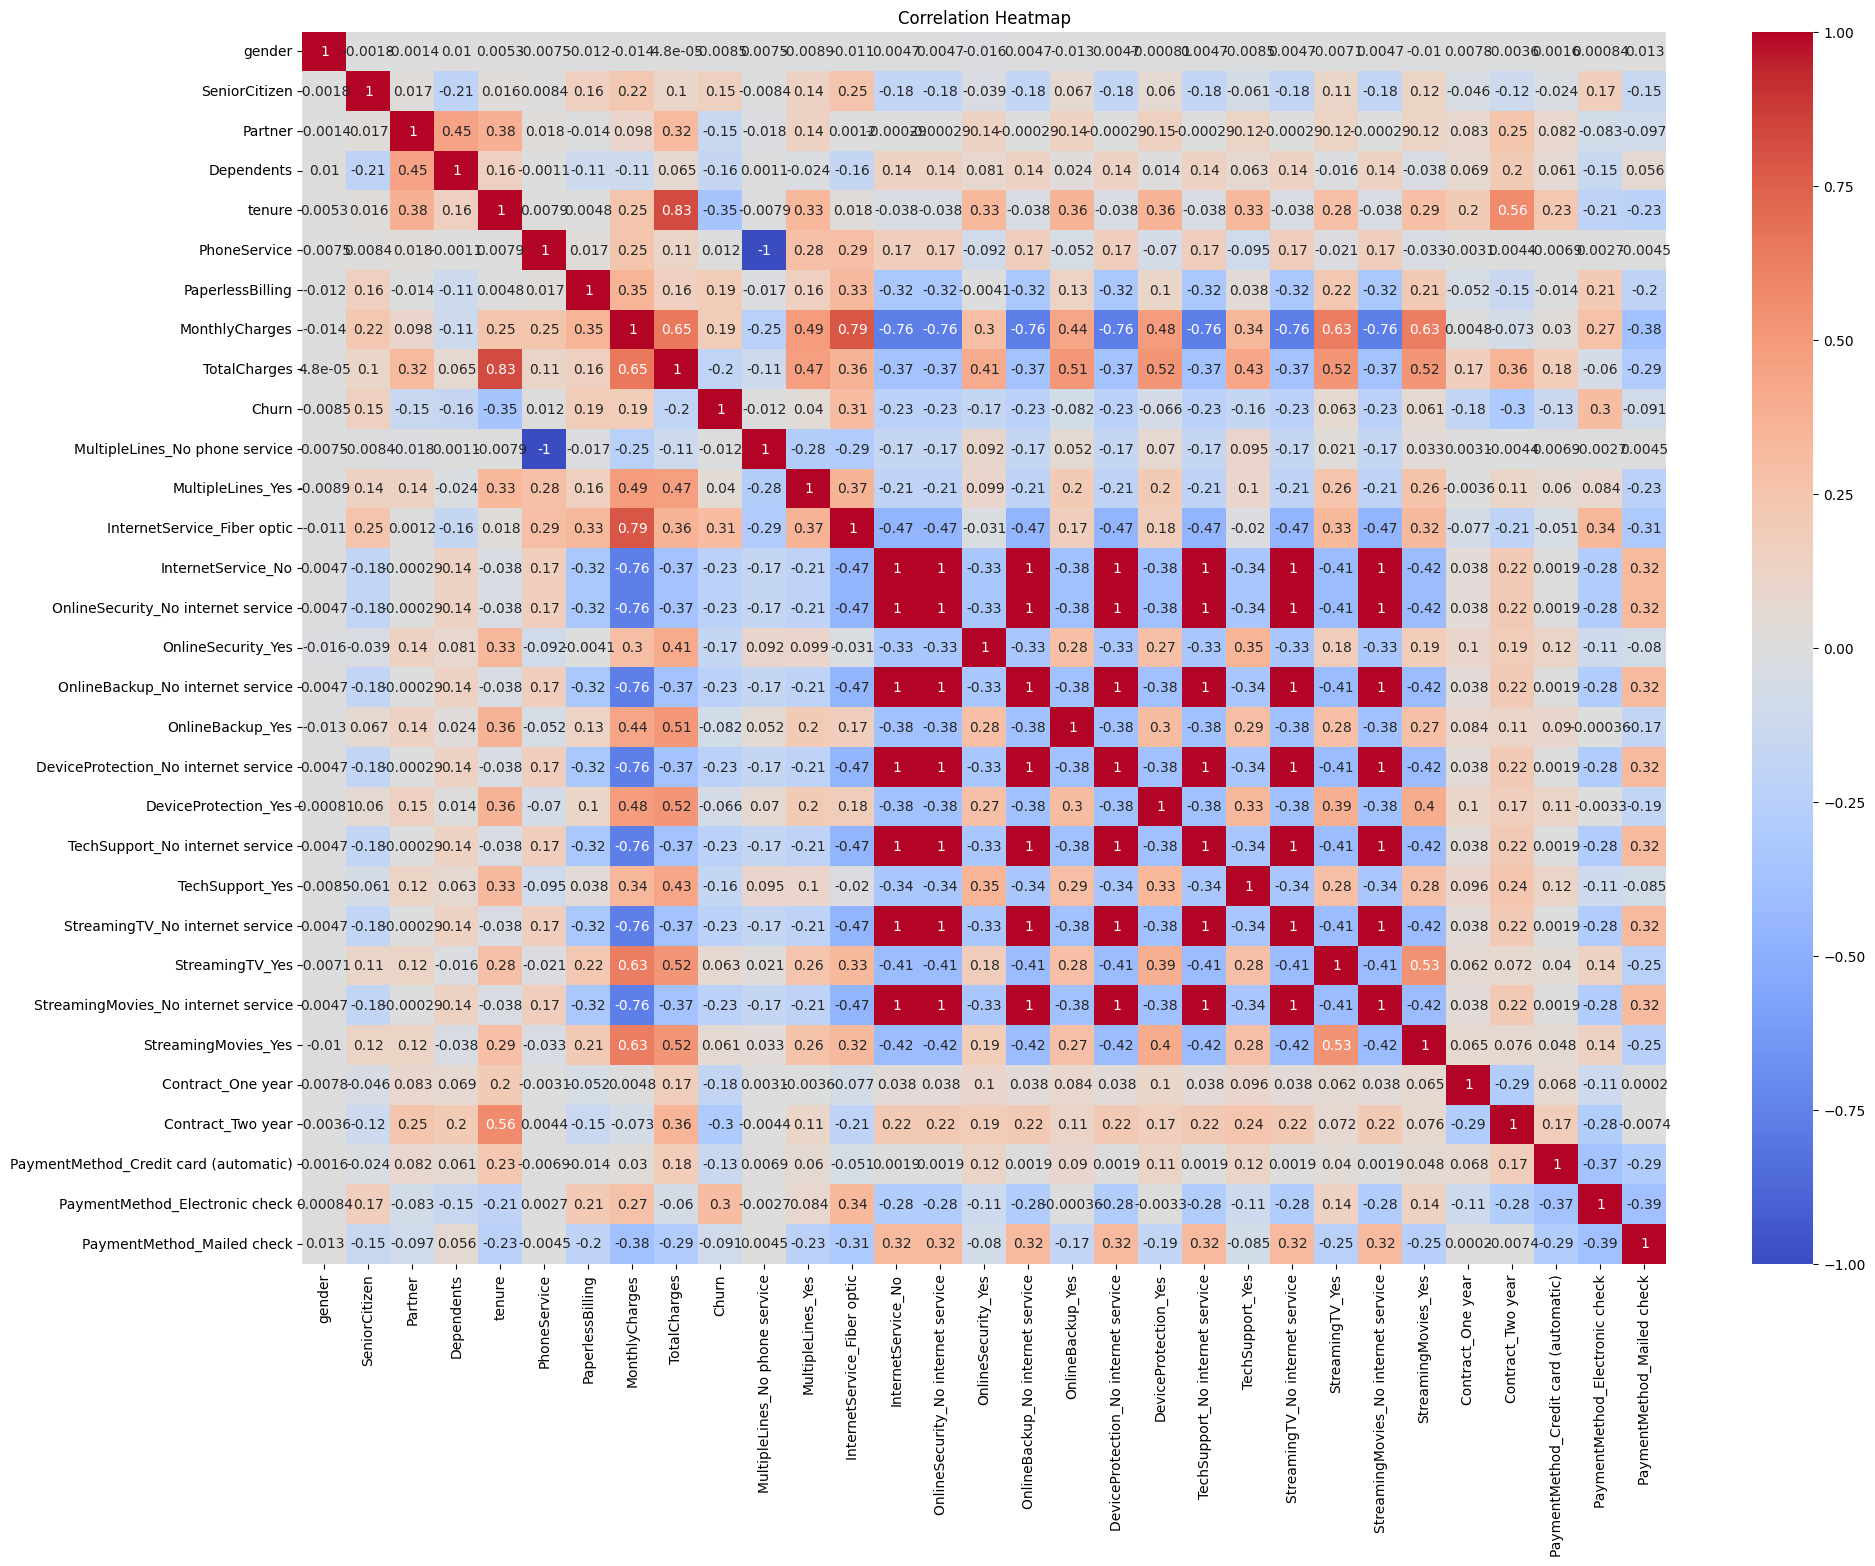

In [6]:
plt.figure(figsize=(22, 16))
sns.heatmap(data.corr(), cmap="coolwarm",annot=True)
plt.title("Correlation Heatmap")
plt.show()

In [7]:


coefficients = pd.DataFrame({
    "Feature": x_train.columns,
    "Coefficient": model.coef_[0]
})

coefficients = coefficients.sort_values(
    by="Coefficient",
    ascending=False
)

print(coefficients)

                                  Feature  Coefficient
10            InternetService_Fiber optic     1.115632
7                            TotalCharges     0.654055
23                    StreamingMovies_Yes     0.394439
21                        StreamingTV_Yes     0.384923
27         PaymentMethod_Electronic check     0.294273
0                           SeniorCitizen     0.259654
9                       MultipleLines_Yes     0.257311
5                        PaperlessBilling     0.247419
1                                 Partner     0.041662
17                   DeviceProtection_Yes     0.035988
15                       OnlineBackup_Yes    -0.038845
28             PaymentMethod_Mailed check    -0.071768
8          MultipleLines_No phone service    -0.081724
26  PaymentMethod_Credit card (automatic)    -0.089845
22    StreamingMovies_No internet service    -0.159085
14       OnlineBackup_No internet service    -0.159085
20        StreamingTV_No internet service    -0.159085
11        